ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

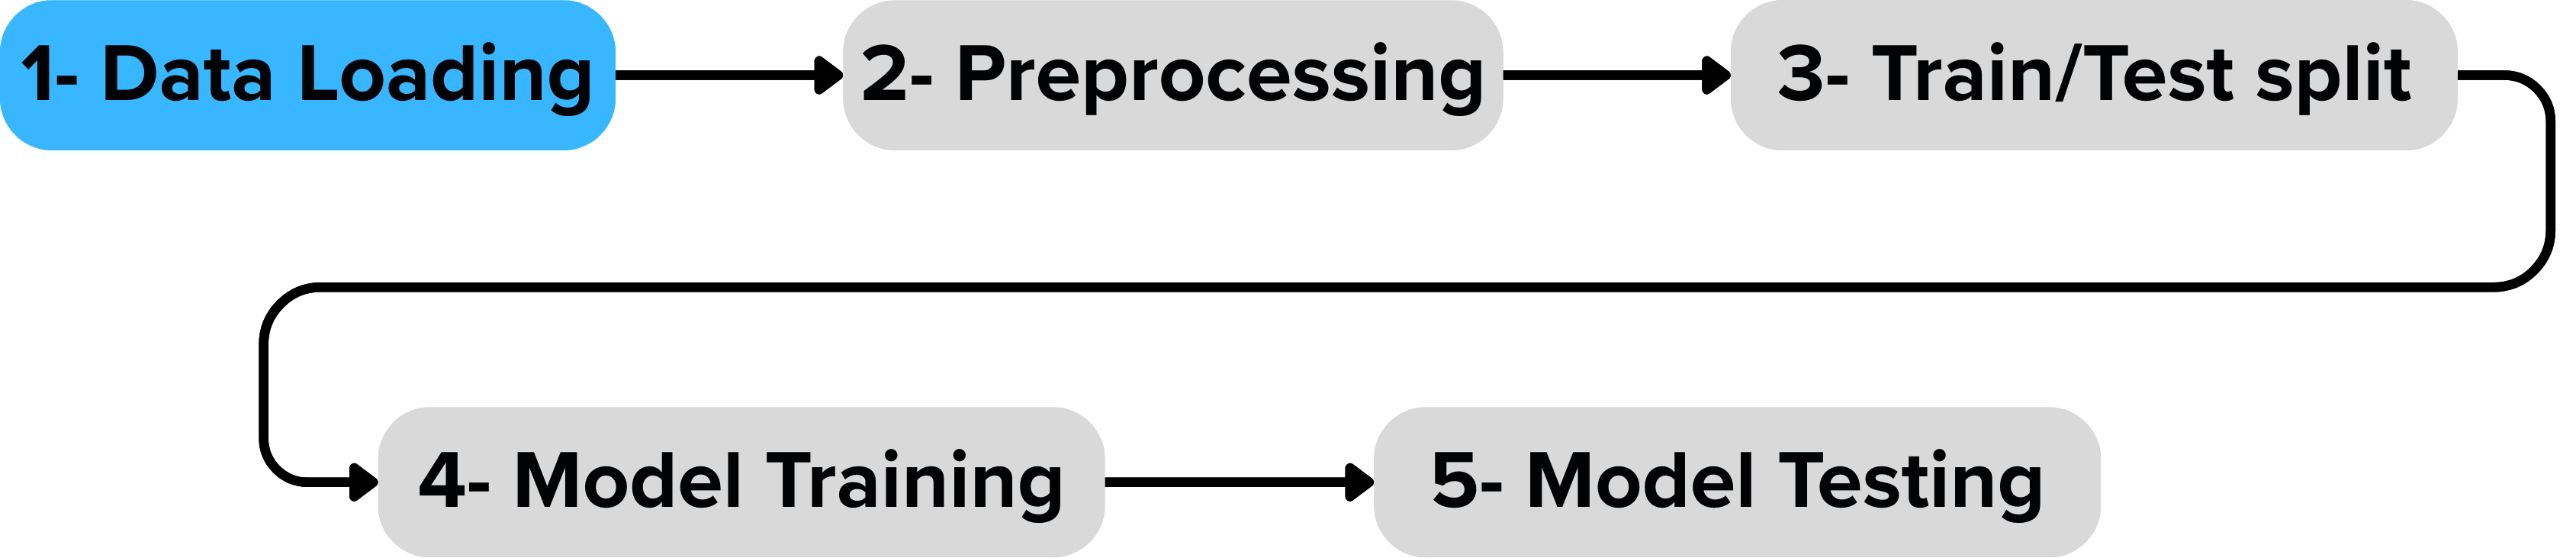

In [40]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [41]:
# Load Dataset

df = pd.read_csv("gym_members_exercise_tracking.csv")

# Display first 5 rows
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### Check Missing Values

In [42]:
# Check all values
print(df.isna())

       Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0    False   False        False       False    False    False        False   
1    False   False        False       False    False    False        False   
2    False   False        False       False    False    False        False   
3    False   False        False       False    False    False        False   
4    False   False        False       False    False    False        False   
..     ...     ...          ...         ...      ...      ...          ...   
968  False   False        False       False    False    False        False   
969  False   False        False       False    False    False        False   
970  False   False        False       False    False    False        False   
971  False   False        False       False    False    False        False   
972  False   False        False       False    False    False        False   

     Session_Duration (hours)  Calories_Burned  Workout_Type  F

In [43]:
print(df.isna().sum())

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


### Check duplicate rows

In [44]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [45]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (973, 15) 

number of rows:  973
number of columns:  15


### Data type of columns

In [46]:
# viewing the data types of columns
df.dtypes

Age                                int64
Gender                               str
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                         str
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

In [47]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])
df['Workout_Type'] = encoder.fit_transform(df['Workout_Type'])

df.head()

df.dtypes




Age                                int64
Gender                             int64
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                       int64
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

### Descriptive summary Statistics

In [48]:
# Statistical summary
df.describe(include='all')

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,0.525180,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,1.494347,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,0.499622,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,1.125472,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,0.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,0.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,0.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,0.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,1.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,2.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,1.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,2.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,1.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,3.000000,35.000000,3.700000,5.000000,3.000000,49.840000


### Univariate Analysis

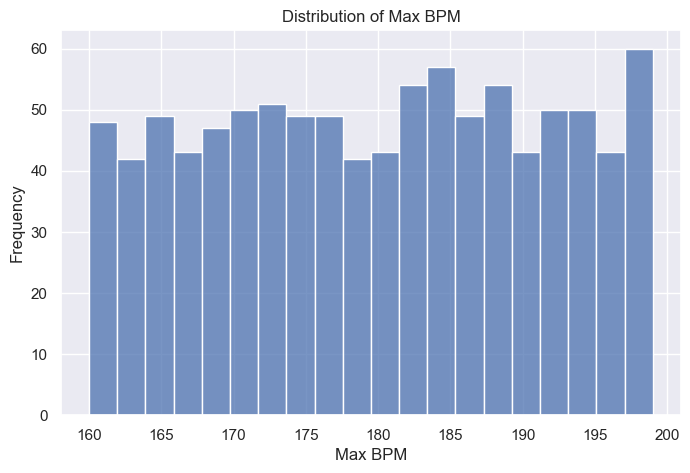

In [49]:

plt.figure(figsize=(8,5))
sns.histplot(df['Max_BPM'], bins=20)
plt.title("Distribution of Max BPM")
plt.xlabel("Max BPM")
plt.ylabel("Frequency")
plt.show()


- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

### Distribution of Revenue

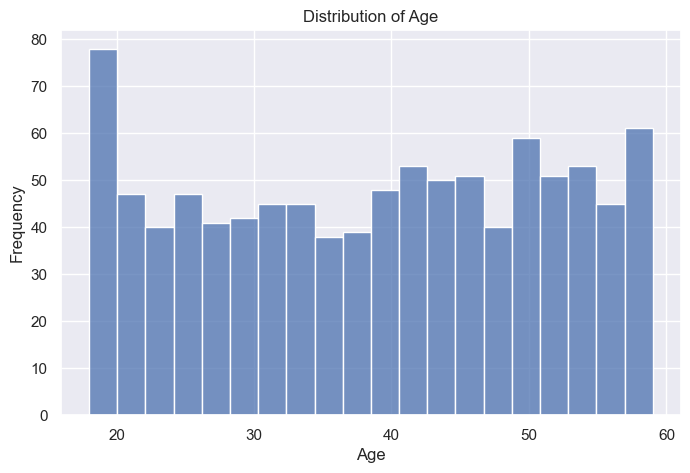

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


## Bivariate Analysis

### Calories Burned by Workout Type

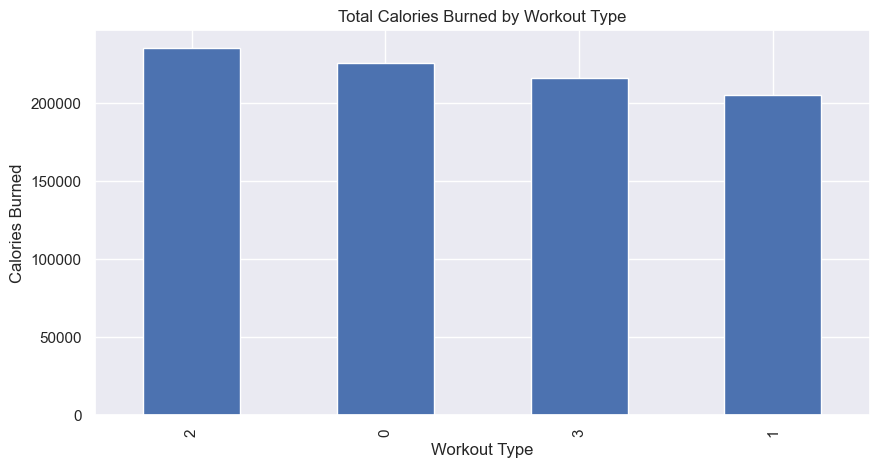

Workout_Type
2    234960.0
0    225551.0
3    215862.0
1    204603.0
Name: Calories_Burned, dtype: float64

In [51]:
workout_calories = df.groupby('Workout_Type')['Calories_Burned'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
workout_calories.plot(kind='bar')
plt.title("Total Calories Burned by Workout Type")
plt.ylabel("Calories Burned")
plt.xlabel("Workout Type")
plt.show()

workout_calories


### Revenue by Product

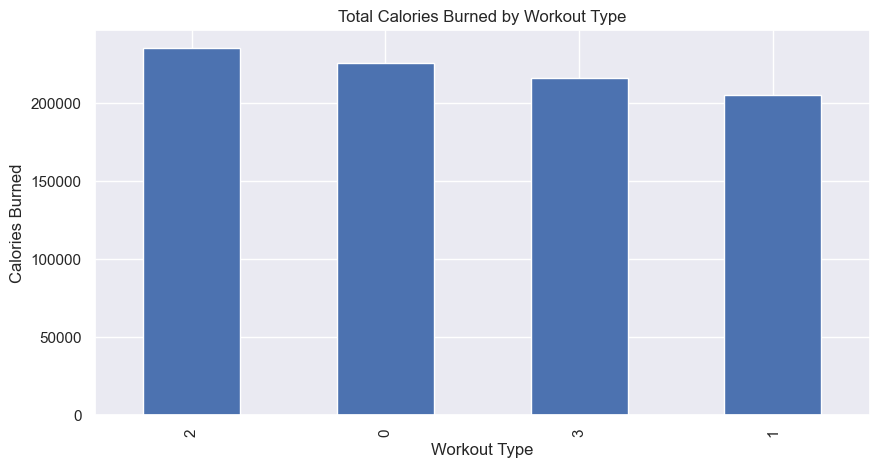

Workout_Type
2    234960.0
0    225551.0
3    215862.0
1    204603.0
Name: Calories_Burned, dtype: float64

In [52]:
workout_calories = df.groupby('Workout_Type')['Calories_Burned'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
workout_calories.plot(kind='bar')
plt.title("Total Calories Burned by Workout Type")
plt.ylabel("Calories Burned")
plt.xlabel("Workout Type")
plt.show()

workout_calories


### Calories by Workout Type

In [53]:
workout_calories = df.groupby('Workout_Type')['Calories_Burned'].sum().sort_values(ascending=False)

workout_calories.head(10)


Workout_Type
2    234960.0
0    225551.0
3    215862.0
1    204603.0
Name: Calories_Burned, dtype: float64

### Boxes vs Revenue Relationship

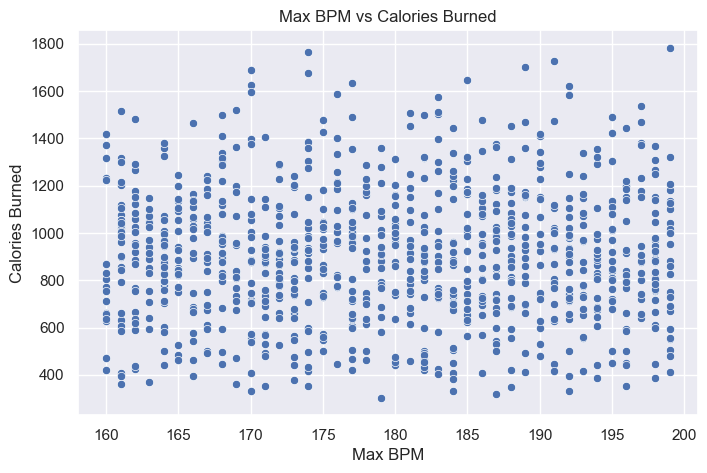

In [54]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Max_BPM', y='Calories_Burned', data=df)
plt.title("Max BPM vs Calories Burned")
plt.xlabel("Max BPM")
plt.ylabel("Calories Burned")
plt.show()


### Correlation Matrix

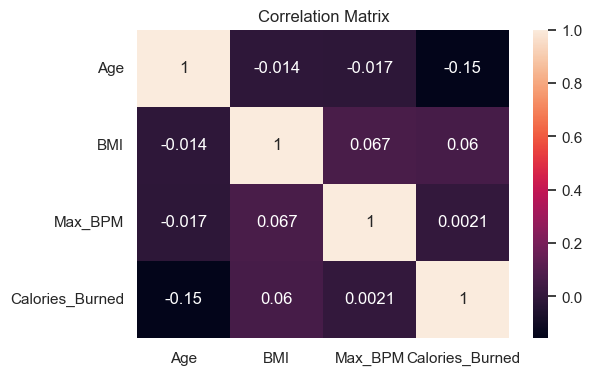

In [55]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age', 'BMI', 'Max_BPM', 'Calories_Burned']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis
### Monthly Revenue Trend

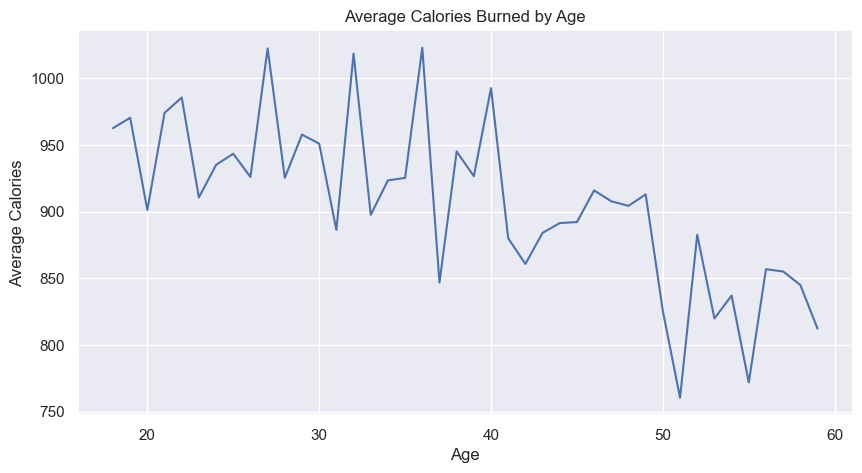

In [56]:
age_calories = df.groupby('Age')['Calories_Burned'].mean()

plt.figure(figsize=(10,5))
age_calories.plot()
plt.title("Average Calories Burned by Age")
plt.ylabel("Average Calories")
plt.show()

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.